In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap,HeatMapWithTime
import numpy as np

In [8]:

df = pd.read_csv("data/cleaned_collision_data.csv")
ped = pd.read_csv("data/pedestrian_collisions.csv")
cyc = pd.read_csv("data/cyclist_collisions.csv")

C:\Users\harsh\AppData\Local\Temp\ipykernel_31528\3434169742.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/cleaned_collision_data.csv")
C:\Users\harsh\AppData\Local\Temp\ipykernel_31528\3434169742.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  ped = pd.read_csv("data/pedestrian_collisions.csv")
C:\Users\harsh\AppData\Local\Temp\ipykernel_31528\3434169742.py:3: DtypeWarning: Columns (25,26,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  cyc = pd.read_csv("data/cyclist_collisions.csv")


BOROUGH TREND ANALYSIS OVER TIME

In [14]:
ped['crash_date'] = pd.to_datetime(ped['crash_date'], errors='coerce')
cyc['crash_date'] = pd.to_datetime(cyc['crash_date'], errors='coerce')

ped['year'] = ped['crash_date'].dt.year
cyc['year'] = cyc['crash_date'].dt.year

In [15]:
ped_year_borough = ped.groupby(['borough', 'year'])[['number_of_pedestrians_injured']].sum().reset_index()

In [16]:
cyc_year_borough = cyc.groupby(['borough', 'year'])[['number_of_cyclist_injured']].sum().reset_index()

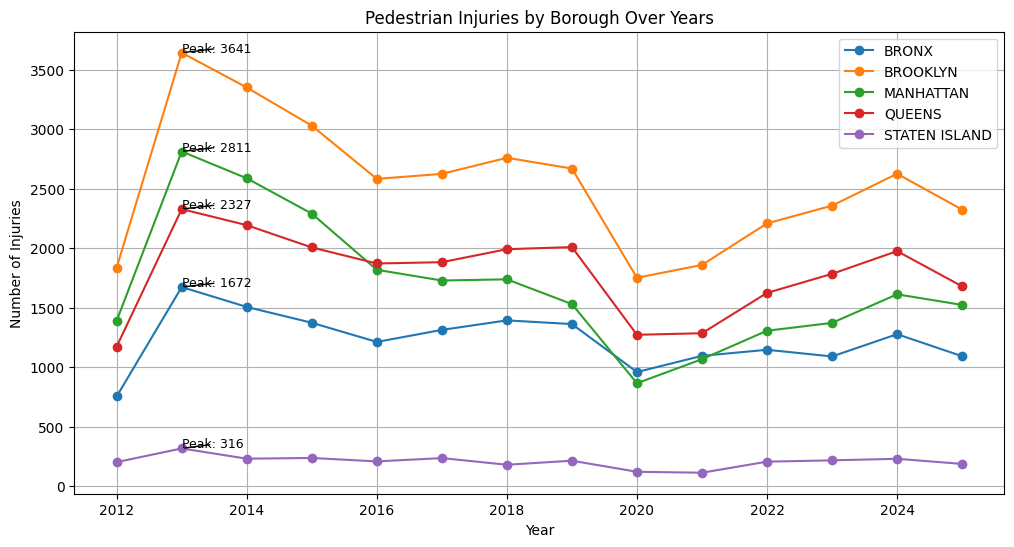

In [25]:
plt.figure(figsize=(12,6))

for b in ped_year_borough['borough'].unique():
    data = ped_year_borough[ped_year_borough['borough'] == b]
    plt.plot(data['year'], data['number_of_pedestrians_injured'], marker='o', label=b)
    peak = data.loc[data['number_of_pedestrians_injured'].idxmax()]
    plt.annotate(f"Peak: {int(peak['number_of_pedestrians_injured'])}", 
                 xy=(peak['year'], peak['number_of_pedestrians_injured']),
                 xytext=(peak['year'], peak['number_of_pedestrians_injured']+5),
                 arrowprops=dict(facecolor='black', arrowstyle='-'),
                 fontsize=9)

plt.title('Pedestrian Injuries by Borough Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Injuries')
plt.legend()
plt.grid(True)
plt.show()

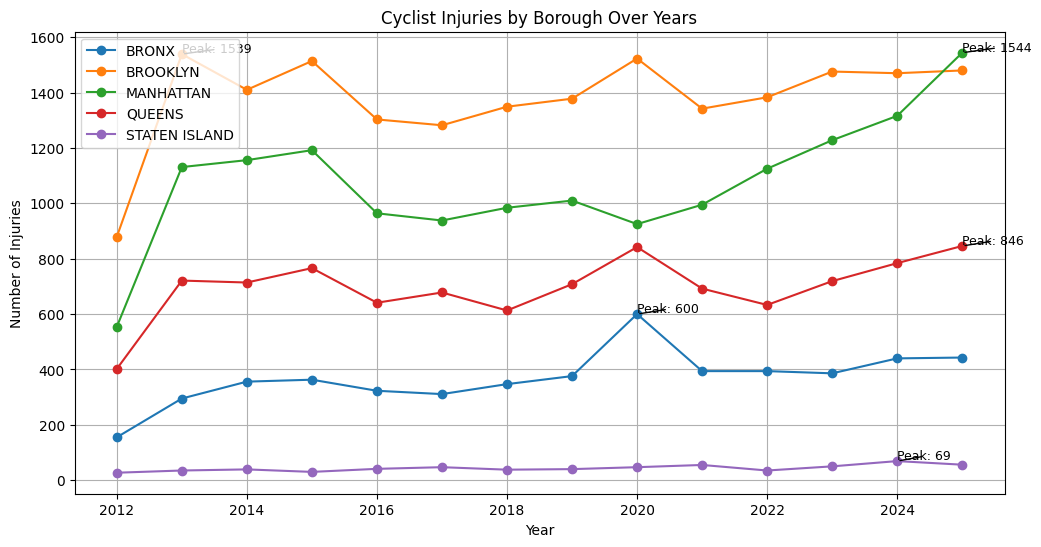

In [24]:
plt.figure(figsize=(12,6))

for b in cyc_year_borough['borough'].unique():
    data = cyc_year_borough[cyc_year_borough['borough'] == b]
    plt.plot(data['year'], data['number_of_cyclist_injured'], marker='o', label=b)
    peak = data.loc[data['number_of_cyclist_injured'].idxmax()]
    plt.annotate(f"Peak: {int(peak['number_of_cyclist_injured'])}", 
                 xy=(peak['year'], peak['number_of_cyclist_injured']),
                 xytext=(peak['year'], peak['number_of_cyclist_injured']+5),
                 arrowprops=dict(facecolor='black', arrowstyle='-'),
                 fontsize=9)

plt.title('Cyclist Injuries by Borough Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Injuries')
plt.legend()
plt.grid(True)
plt.show()


BOROUGH and TIME OF DAY ANALYSIS

In [32]:
for df_user in [ped, cyc]:
    if 'time_of_day' not in df_user.columns:
        df_user['hour'] = pd.to_datetime(df_user['crash_time'], format='%H:%M', errors='coerce').dt.hour
        def time_of_day(h):
            if 5 <= h < 12:
                return 'Morning'
            elif 12 <= h < 17:
                return 'Afternoon'
            elif 17 <= h < 21:
                return 'Evening'
            else:
                return 'Night'
        df_user['time_of_day'] = df_user['hour'].apply(time_of_day)

In [33]:
ped_borough_time = ped.groupby(['borough','time_of_day'])[['number_of_pedestrians_injured']].sum().reset_index()
cyc_borough_time = cyc.groupby(['borough','time_of_day'])[['number_of_cyclist_injured']].sum().reset_index()




In [34]:
boroughs = ped_borough_time['borough'].unique()
time_order = ['Morning','Afternoon','Evening','Night']

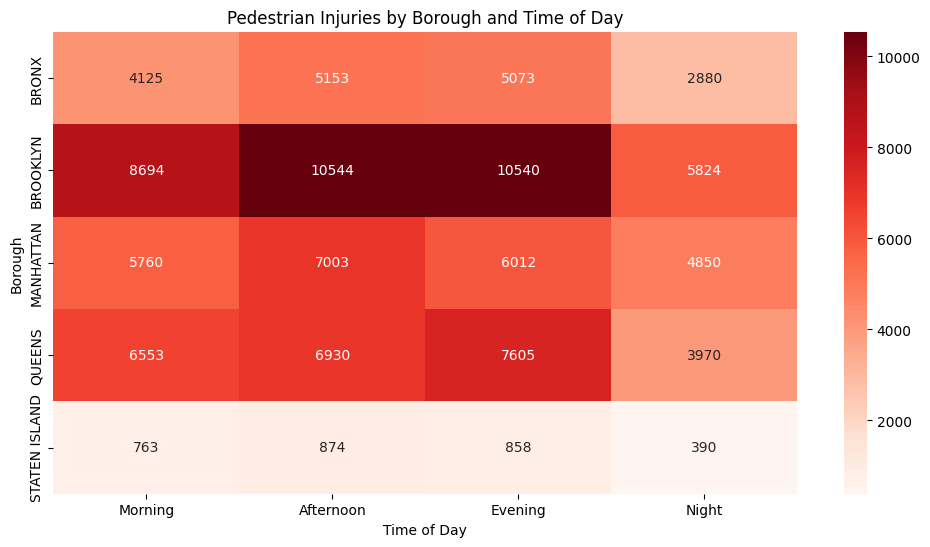

In [36]:
plt.figure(figsize=(12,6))
ped_pivot = ped_borough_time.pivot(index='borough', columns='time_of_day', values='number_of_pedestrians_injured').reindex(index=boroughs, columns=time_order)
sns.heatmap(ped_pivot, annot=True, fmt='g', cmap='Reds')
plt.title('Pedestrian Injuries by Borough and Time of Day')
plt.ylabel('Borough')
plt.xlabel('Time of Day')
plt.show()

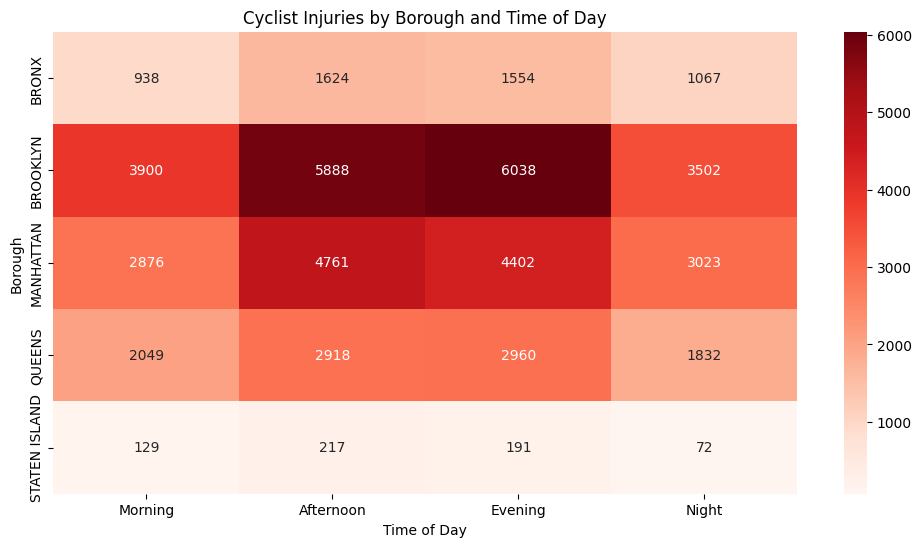

In [38]:
plt.figure(figsize=(12,6))
cyc_pivot = cyc_borough_time.pivot(index='borough', columns='time_of_day', values='number_of_cyclist_injured').reindex(index=boroughs, columns=time_order)
sns.heatmap(cyc_pivot, annot=True, fmt='g', cmap='Reds')
plt.title('Cyclist Injuries by Borough and Time of Day')
plt.ylabel('Borough')
plt.xlabel('Time of Day')
plt.show()

TOP CONTRIBUTING FACTORS ANALYSIS

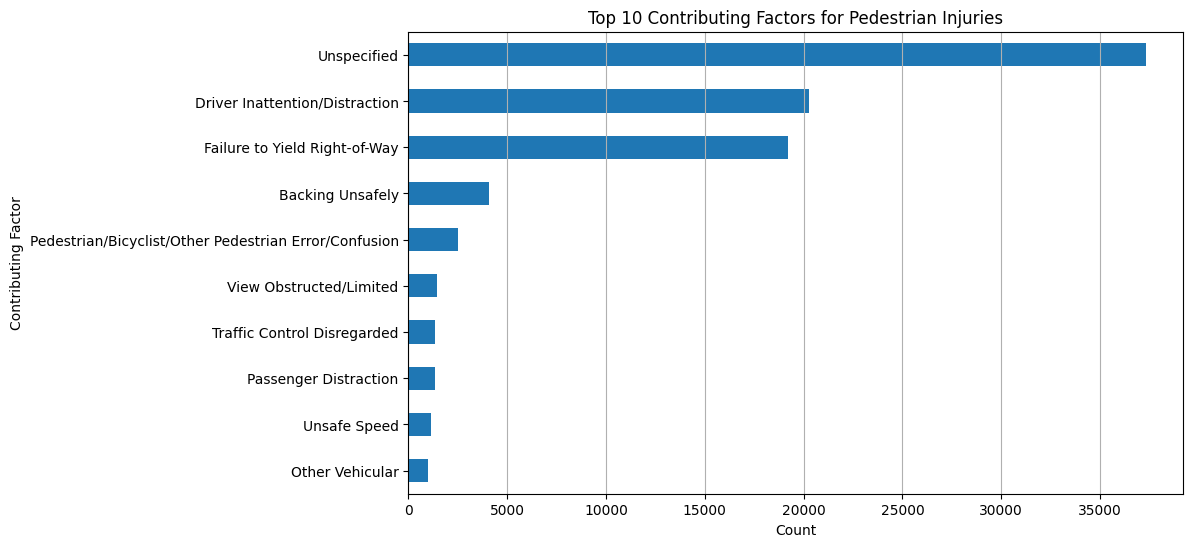

In [39]:
ped_factors = ped['contributing_factor_vehicle_1'].value_counts().head(10)

plt.figure(figsize=(10,6))
ped_factors.sort_values().plot(kind='barh')
plt.title('Top 10 Contributing Factors for Pedestrian Injuries')
plt.xlabel('Count')
plt.ylabel('Contributing Factor')
plt.grid(axis='x')
plt.show()

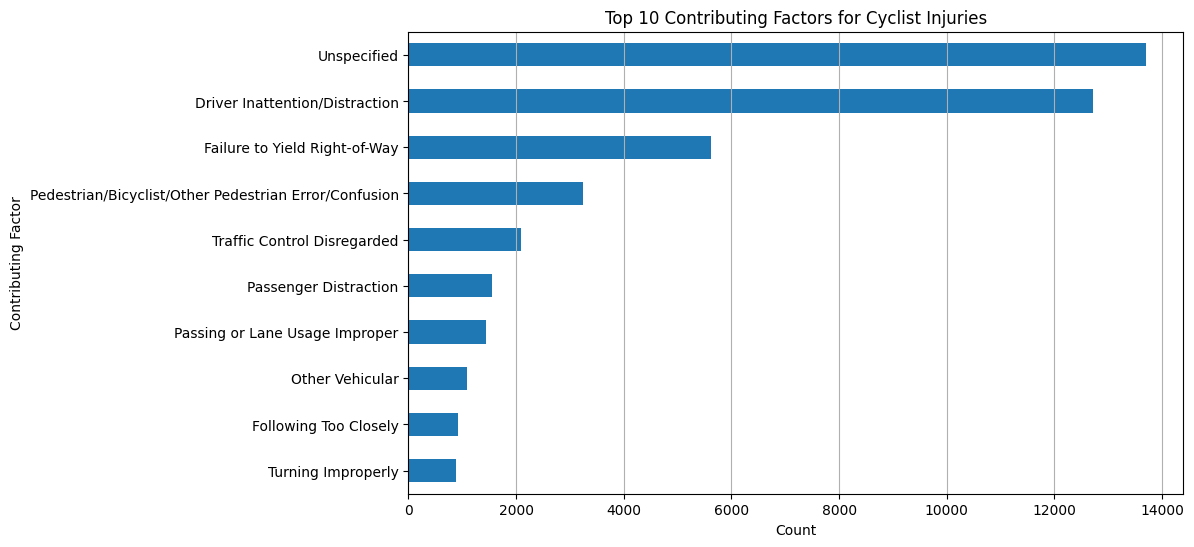

In [40]:
cyc_factors = cyc['contributing_factor_vehicle_1'].value_counts().head(10)

plt.figure(figsize=(10,6))
cyc_factors.sort_values().plot(kind='barh')
plt.title('Top 10 Contributing Factors for Cyclist Injuries')
plt.xlabel('Count')
plt.ylabel('Contributing Factor')
plt.grid(axis='x')
plt.show()